In [1]:
import numpy as np

import os

import xarray as xr

import glob

import matplotlib.pyplot as plt

import pandas as pd

from matplotlib.colors import BoundaryNorm

import matplotlib.colors as mcolors

import dask.array as da

import pickle

from scipy.stats import t

import matplotlib.ticker as ticker

import cartopy.crs as ccrs

import cartopy.feature as cfeature

import seaborn as sns

In [2]:
with open('/home/annierosen16/master.pkl', 'rb') as f:
    
    master = pickle.load(f)
    
dryapes = master[master['dryape'] == True]

wetapes = master[master['wetape'] == True]

### evaporation handling

In [3]:
path = '/home/annierosen16/data/era5sgp/era5_sl_ET'

files = sorted(glob.glob(f"{path}/*.nc"))

evaporation = xr.open_mfdataset(files, combine="by_coords")

evaporation['valid_time'] = evaporation['valid_time'] - pd.Timedelta(hours=6)

# # compute local solar time offset (in hours) from longitude

# offset_hours = evaporation['longitude'] / 15.0  # east positive

# offset = xr.apply_ufunc(
    
#     lambda x: pd.to_timedelta(x, unit="h"),
    
#     offset_hours
# )

# # create new coordinate: local solar time

# evaporation = evaporation.assign_coords(
    
#     local_time=evaporation['valid_time'] + offset
# )

In [4]:
# lat = 39

# print(evaporation.sel(latitude=lat, longitude=-105)['valid_time'].data[0])

# print("")

# print(evaporation.sel(latitude=lat, longitude=-105)['cst_time'].data[0])

# print("")

# print(evaporation.sel(latitude=lat, longitude=-95)['local_time'].data[0])

# print("")

# print(evaporation.sel(latitude=lat, longitude=-105)['local_time'].data[0])

In [5]:
e_hourly = evaporation['e'] * -1  # hourly accumulations in m, multiply by -1 to indicate positive evaporation 

# instantaneous approximation at 11:00 = midpoint of 10-11 & 11-12

e_inst = (e_hourly + e_hourly.shift(valid_time=-1)) / 2.0

# convert to mm/day

e_inst_mm_per_day = e_inst * 1000 * 24

e_inst_mm_per_day.attrs['units'] = 'mm/day'

e_inst_mm_per_day.attrs['long_name'] = 'Instantaneous evaporation approximation (central)'

evaporation['evap_inst_mm_per_day'] = e_inst_mm_per_day

### precipitation handling

In [6]:
base_path = '/home/annierosen16/data/era5sgp/era5_sl_hourly_precip_full_sgp'

file_pattern = f"{base_path}/20*"

file_list = glob.glob(file_pattern)

precip = xr.open_mfdataset(file_list, combine='by_coords', chunks={'time': 24})

precip = precip.assign_coords(valid_time=precip.valid_time - pd.Timedelta(hours=6))

In [7]:
p_hourly = precip['tp']  # hourly accumulations in m

# instantaneous approximation at 11:00 = midpoint of 10-11 & 11-12

p_inst = (p_hourly + p_hourly.shift(valid_time=-1)) / 2.0

# convert to mm/day

p_inst_mm_per_day = p_inst * 1000 * 24

p_inst_mm_per_day.attrs['units'] = 'mm/day'

p_inst_mm_per_day.attrs['long_name'] = 'Instantaneous evaporation approximation (central)'

precip['p_inst_mm_per_day'] = p_inst_mm_per_day

### vimdf handling

In [8]:
path = '/home/annierosen16/data/era5sgp/era5_sl_hourly_vimdf_and_tcwv_full_sgp'

files = sorted(glob.glob(f"{path}/*.nc"))

# mbvars = moisture budget variables 

mbvars = xr.open_mfdataset(files, combine="by_coords")

mbvars['valid_time'] = mbvars['valid_time'] - pd.Timedelta(hours=6)

# for vimdf, units are kg/m^2*s = mm/s, so just need to convert from s -> day

# 1/s * 60s/min * 60min/1hr * 24hr/day

sec_to_day = 60 * 60 * 24

mbvars['vimdf_mm_per_day'] = mbvars['vimdf'] * sec_to_day

### tcwv handling

In [9]:
tcwv = mbvars['tcwv']

time = mbvars['valid_time']

dt_seconds = (time.values[1] - time.values[0]) / np.timedelta64(1, 's')  # e.g. 3600.0

# central difference: (f_{t+1} - f_{t-1}) / (2*dt)

central = (tcwv.shift(valid_time=-1) - tcwv.shift(valid_time=1)) / (2 * dt_seconds)

# one-sided forward/backward for endpoints

forward = (tcwv.shift(valid_time=-1) - tcwv) / dt_seconds

backward = (tcwv - tcwv.shift(valid_time=1)) / dt_seconds

# combine: central where available, otherwise forward/backward

d_tcwv_dt_per_s = central.where(~np.isnan(central), other=forward)

d_tcwv_dt_per_s = d_tcwv_dt_per_s.where(~np.isnan(d_tcwv_dt_per_s), other=backward)

# convert from mm per second -> mm per day (multiply by seconds per day)

seconds_per_day = 24 * 3600

d_tcwv_dt_mm_per_day = d_tcwv_dt_per_s * seconds_per_day

# set attributes / name

d_tcwv_dt_mm_per_day = d_tcwv_dt_mm_per_day.rename('tcwv_rate_mm_per_day')

d_tcwv_dt_mm_per_day.attrs['units'] = 'mm day-1'

d_tcwv_dt_mm_per_day.attrs['long_name'] = 'total column water vapor tendency (finite difference)'

mbvars['tcwv_rate_mm_per_day'] = d_tcwv_dt_mm_per_day

In [10]:
# y = mbvars['tcwv'].sel(latitude = 36, longitude = -101).values

# x = mbvars['tcwv_rate_mm_per_day'].sel(latitude = 36, longitude = -101).values

# y[100:105], x[100:105]

### is the moisture budget balanced?

In [11]:
# Example: pick indices or coordinate values

lat_pt = 33

lon_pt = -95

time_pt = mbvars.valid_time.values[6060]

print(lat_pt, lon_pt, time_pt)

print("")

# P and E

P = precip['p_inst_mm_per_day'].sel(latitude=lat_pt, longitude=lon_pt, valid_time=time_pt).values

E = evaporation['evap_inst_mm_per_day'].sel(latitude=lat_pt, longitude=lon_pt, valid_time=time_pt).values

# moisture tendency and divergence

tcwv_tend = mbvars['tcwv_rate_mm_per_day'].sel(latitude=lat_pt, longitude=lon_pt, valid_time=time_pt).values

vimdf_val = mbvars['vimdf_mm_per_day'].sel(latitude=lat_pt, longitude=lon_pt, valid_time=time_pt).values

lhs = P - E

rhs = - tcwv_tend - vimdf_val

print(f"P - E  = {lhs:.3f} mm/day")

print("")

print(f"-tcwv_rate - vimdf = {rhs:.3f} mm/day")

print("")

print(f"Difference (residual) = {lhs - rhs:.3f} mm/day")

33 -95 2002-08-08T06:00:00.000000000

P - E  = -2.257 mm/day

-tcwv_rate - vimdf = -0.974 mm/day

Difference (residual) = -1.284 mm/day


#### notes: for individual dates and locations, very much not balanced

### what about warm-season average moisture budget per gridpoint?

In [12]:
# Spatial bounds

lat_bounds = (39, 30)

lon_bounds = (-105, -95)

# Temporal bounds: warm season May (5) -> September (9)

warm_months = [5, 6, 7, 8, 9]

In [13]:
mbvars_sel = mbvars.sel(latitude=slice(lat_bounds[0], lat_bounds[1]), longitude=slice(lon_bounds[0], lon_bounds[1]))

precip_sel = precip.sel(latitude=slice(lat_bounds[0], lat_bounds[1]), longitude=slice(lon_bounds[0], lon_bounds[1]))

evap_sel = evaporation.sel(latitude=slice(lat_bounds[0], lat_bounds[1]), longitude=slice(lon_bounds[0], lon_bounds[1]))

mbvars_sel = mbvars_sel.sel(valid_time=mbvars_sel['valid_time'].dt.month.isin(warm_months))

precip_sel = precip_sel.sel(valid_time=precip_sel['valid_time'].dt.month.isin(warm_months))

evap_sel = evap_sel.sel(valid_time=evap_sel['valid_time'].dt.month.isin(warm_months))

In [14]:
P = precip_sel['p_inst_mm_per_day']

E = evap_sel['evap_inst_mm_per_day']

tcwv_rate = mbvars_sel['tcwv_rate_mm_per_day']

vimdf = mbvars_sel['vimdf_mm_per_day']  # make sure it is in mm/day

# Compute residual: LHS - RHS = (P - E) - (-tcwv_rate - vimdf)

residual = (P - E) - (-tcwv_rate - vimdf)

In [15]:
residual_spatial_mean = residual.mean(dim=['latitude', 'longitude'])

# Temporal + spatial average (overall mean)

residual_mean = residual_spatial_mean.mean(dim='valid_time')

print(f"Average residual over warm season and domain: {residual_mean.values:.3f} mm/day")

Average residual over warm season and domain: -0.296 mm/day


In [16]:
residual_grid_mean = residual.mean(dim='valid_time')

print(residual_grid_mean.shape)

(37, 41)


In [17]:
residual_grid = residual_grid_mean.load()

abs_residual_grid = abs(residual_grid)

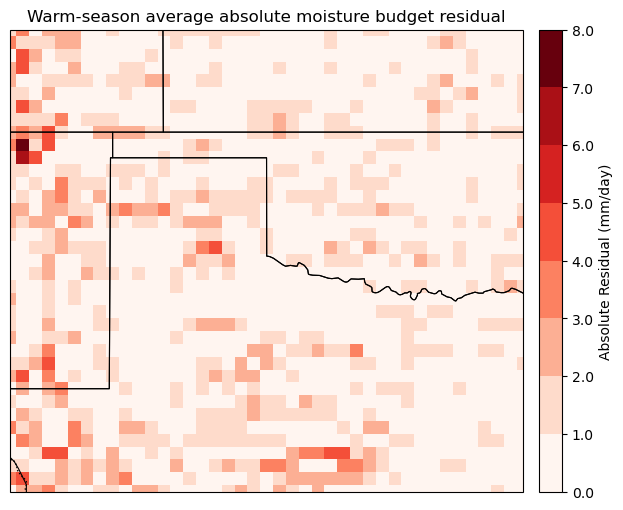

In [18]:
# Compute max value of abs_residual_grid

max_val = abs_residual_grid.max().values

min_val = 0

# Define discrete bins from 0 to max value

# Choose step = 1 mm/day or smaller if you want finer bins

step = 1.0

bin_edges = np.arange(min_val, max_val + step, step)

# Ensure the last bin edge is exactly max_val

if bin_edges[-1] < max_val:
    
    bin_edges = np.append(bin_edges, max_val)

# Create colormap and norm

cmap = plt.get_cmap('Reds', len(bin_edges) - 1)

norm = mcolors.BoundaryNorm(bin_edges, cmap.N)

# Create figure and axis

fig = plt.figure(figsize=(10, 6))

ax = plt.axes(projection=ccrs.PlateCarree())

# Plot heatmap
pcm = ax.pcolormesh(
    
    abs_residual_grid.longitude,
    
    abs_residual_grid.latitude,
    
    abs_residual_grid,
    
    cmap=cmap,
    
    norm=norm,
    
    transform=ccrs.PlateCarree()
)

# Colorbar

cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.02, fraction=0.05)

cbar.set_label('Absolute Residual (mm/day)')

cbar.set_ticks(bin_edges)

# Format labels at the edges
tick_labels = [f"{b:.1f}" for b in bin_edges]

cbar.ax.set_yticklabels(tick_labels)

# Add geographic features

ax.coastlines()

ax.add_feature(cfeature.BORDERS, linestyle=':')

states_provinces = cfeature.NaturalEarthFeature(
    
    category='cultural',
    
    name='admin_1_states_provinces_lakes',
    
    scale='50m',
    
    facecolor='none'
)

ax.add_feature(states_provinces, edgecolor='black', linewidth=0.8)

# Set map extent
ax.set_extent([lon_bounds[0], lon_bounds[1], lat_bounds[0], lat_bounds[1]], crs=ccrs.PlateCarree())

ax.set_title('Warm-season average absolute moisture budget residual')

plt.show()

### what do average dry and wet APE diurnal cycle moisture budget values look like?

In [19]:
# Make sure xarrays have 'valid_time' as datetime64

mbvars['valid_time'] = pd.to_datetime(mbvars['valid_time'].values)

precip['valid_time'] = pd.to_datetime(precip['valid_time'].values)

evaporation['valid_time'] = pd.to_datetime(evaporation['valid_time'].values)

In [20]:
# Create xarray coordinates

lats = np.unique(master['latitude'])

lons = np.unique(master['longitude'])

times = np.unique(master['date'])

# Initialize masks: False everywhere

dry_mask = xr.DataArray(False, dims=('valid_time','latitude','longitude'),
                        coords={'valid_time':times, 'latitude':lats, 'longitude':lons})

wet_mask = xr.DataArray(False, dims=('valid_time','latitude','longitude'),
                        coords={'valid_time':times, 'latitude':lats, 'longitude':lons})

# Fill masks using master DataFrame

for idx, row in master.iterrows():
    
    t = np.datetime64(row['date'])
    
    lat = row['latitude']
    
    lon = row['longitude']
    
    # Only update if dryape/wetape is True
    if row['dryape']:
        
        dry_mask.loc[dict(valid_time=t, latitude=lat, longitude=lon)] = True
    
    if row['wetape']:
        
        wet_mask.loc[dict(valid_time=t, latitude=lat, longitude=lon)] = True

In [21]:
dry_mask_hourly = dry_mask.reindex(valid_time=mbvars.valid_time, method="ffill")

wet_mask_hourly = wet_mask.reindex(valid_time=mbvars.valid_time, method="ffill")

In [22]:
# Mask the variables: set values to NaN where mask is False

tcwv_dry = mbvars['tcwv_rate_mm_per_day'].where(dry_mask_hourly)

vimdf_dry = mbvars['vimdf_mm_per_day'].where(dry_mask_hourly)

precip_dry = precip['p_inst_mm_per_day'].where(dry_mask_hourly)

evap_dry = evaporation['evap_inst_mm_per_day'].where(dry_mask_hourly)

tcwv_wet = mbvars['tcwv_rate_mm_per_day'].where(wet_mask_hourly)

vimdf_wet = mbvars['vimdf_mm_per_day'].where(wet_mask_hourly)

precip_wet = precip['p_inst_mm_per_day'].where(wet_mask_hourly)

evap_wet = evaporation['evap_inst_mm_per_day'].where(wet_mask_hourly)

In [23]:
# ---- function: compute diurnal mean across all gridpoints ----

def hourly_diurnal_mean(var_da):
    
    # assign hour coordinate
    
    da = var_da.assign_coords(hour=var_da['valid_time'].dt.hour)
    
    # group by hour and average over time+space (skip NaNs)
    
    diurnal = da.groupby('hour').mean(dim=('valid_time','latitude','longitude'), skipna=True)
    
    # ensure full 0..23 hours
    
#     diurnal = diurnal.reindex(hour=np.arange(24))
    
    return diurnal


# ---- Dry APE ----

tcwv_dry_diurnal   = hourly_diurnal_mean(tcwv_dry)

vimdf_dry_diurnal  = hourly_diurnal_mean(vimdf_dry)

precip_dry_diurnal = hourly_diurnal_mean(precip_dry)

evap_dry_diurnal   = hourly_diurnal_mean(evap_dry)

# ---- Wet APE ----

tcwv_wet_diurnal   = hourly_diurnal_mean(tcwv_wet)

vimdf_wet_diurnal  = hourly_diurnal_mean(vimdf_wet)

precip_wet_diurnal = hourly_diurnal_mean(precip_wet)

evap_wet_diurnal   = hourly_diurnal_mean(evap_wet)

In [24]:
# ---- Dry APE ----

tcwv_dry_diurnal   = hourly_diurnal_mean(tcwv_dry).load()

vimdf_dry_diurnal  = hourly_diurnal_mean(vimdf_dry).load()

precip_dry_diurnal = hourly_diurnal_mean(precip_dry).load()

evap_dry_diurnal   = hourly_diurnal_mean(evap_dry).load()

residual_dry = (precip_dry_diurnal.data - evap_dry_diurnal.data) - (- tcwv_dry_diurnal.data - vimdf_dry_diurnal.data)

print("all dry ape moisture budget arrays loaded")

# ---- Wet APE ----

tcwv_wet_diurnal   = hourly_diurnal_mean(tcwv_wet).load()

vimdf_wet_diurnal  = hourly_diurnal_mean(vimdf_wet).load()

precip_wet_diurnal = hourly_diurnal_mean(precip_wet).load()

evap_wet_diurnal   = hourly_diurnal_mean(evap_wet).load()

residual_wet = (precip_wet_diurnal.data - evap_wet_diurnal.data) - (- tcwv_wet_diurnal.data - vimdf_wet_diurnal.data)

print("all wet ape moisture budget arrays loaded")

all dry ape moisture budget arrays loaded
all wet ape moisture budget arrays loaded


In [35]:
with open('/home/annierosen16/self_calculated_mfc.pkl', 'rb') as f:
    
    self_calculated_mfc_dry, self_calculated_mfc_wet = pickle.load(f)

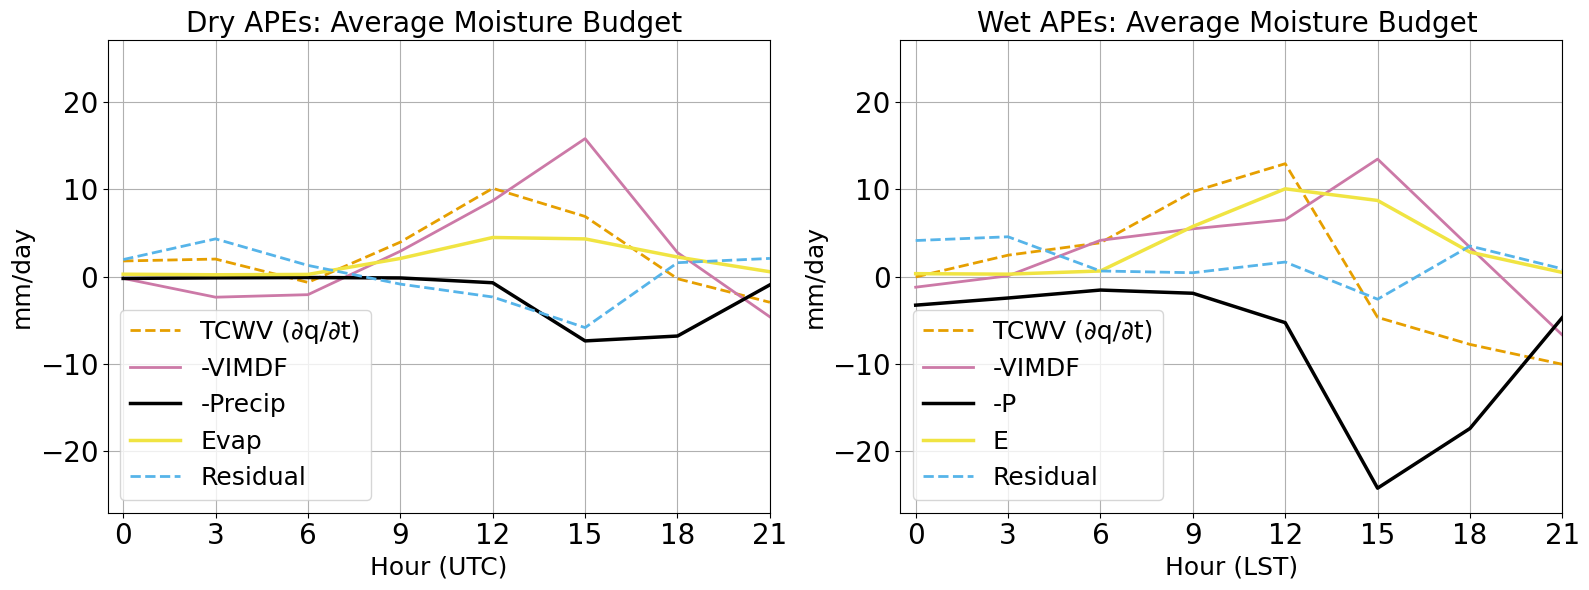

In [28]:
def plot_diurnal_cycle(tcwv_dry, mfc_dry, precip_dry, evap_dry,
                        tcwv_wet, mfc_wet, precip_wet, evap_wet,
                        hours, title_suffix='', data_already_3h=False):

    # --- Calculate residuals ---
    
    residual_dry = (precip_dry - evap_dry) + tcwv_dry - mfc_dry
    
    residual_wet = (precip_wet - evap_wet) + tcwv_wet - mfc_wet

    # --- Prepare arrays for plotting ---
    if data_already_3h:
        hours_plot = hours
        tcwv_dry_plot = tcwv_dry
        tcwv_wet_plot = tcwv_wet
        precip_dry_plot = precip_dry
        precip_wet_plot = precip_wet
        evap_dry_plot = evap_dry
        evap_wet_plot = evap_wet
        mfc_dry_plot = mfc_dry
        mfc_wet_plot = mfc_wet
        residual_dry_plot = residual_dry
        residual_wet_plot = residual_wet
    else:
        hours_plot = hours[::3]
        tcwv_dry_plot = tcwv_dry[::3]
        tcwv_wet_plot = tcwv_wet[::3]
        precip_dry_plot = precip_dry[::3]
        precip_wet_plot = precip_wet[::3]
        evap_dry_plot = evap_dry[::3]
        evap_wet_plot = evap_wet[::3]
        mfc_dry_plot = mfc_dry[::3]
        mfc_wet_plot = mfc_wet[::3]
        residual_dry_plot = residual_dry[::3]
        residual_wet_plot = residual_wet[::3]

    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    xticks = np.arange(0, 24, 3)

    # ======================
    # Dry APE panel
    # ======================
    ax = axes[0]
    ax.plot(hours_plot, tcwv_dry_plot, label='TCWV (∂q/∂t)', color='#E69F00', linestyle='--', linewidth=2)
    ax.plot(hours_plot, mfc_dry_plot, label='-VIMDF', color='#CC79A7', linewidth=2)
    ax.plot(hours_plot, -precip_dry_plot, label='-Precip', color='#000000', linewidth=2.5)
    ax.plot(hours_plot, evap_dry_plot, label='Evap', color='#F0E442', linewidth=2.5)
    ax.plot(hours_plot, residual_dry_plot, label='Residual', color='#56B4E9', linestyle='--', linewidth=2)

    ax.set_xticks(xticks)
    ax.set_xlim(-0.5, 21)

    ax.set_xlabel('Hour (UTC)', fontsize=18)
    ax.set_ylabel('mm/day', fontsize=18)   # <<--- Y-axis label
    ax.set_title(f'Dry APEs: Average Moisture Budget {title_suffix}', fontsize=20)
    ax.tick_params(axis='both', labelsize=20)

    ax.grid(True)
    ax.legend(loc="lower left", fontsize=18)

    # ======================
    # Wet APE panel
    # ======================
    ax = axes[1]
    ax.plot(hours_plot, tcwv_wet_plot, label='TCWV (∂q/∂t)', color='#E69F00', linestyle='--', linewidth=2)
    ax.plot(hours_plot, mfc_wet_plot, label='-VIMDF', color='#CC79A7', linewidth=2)
    ax.plot(hours_plot, -precip_wet_plot, label='-P', color='#000000', linewidth=2.5)
    ax.plot(hours_plot, evap_wet_plot, label='E', color='#F0E442', linewidth=2.5)
    ax.plot(hours_plot, residual_wet_plot, label='Residual', color='#56B4E9', linestyle='--', linewidth=2)

    ax.set_xticks(xticks)
    ax.tick_params(axis="y", labelleft=True)
    ax.set_xlim(-0.5, 21)
    ax.set_ylim(-27, 27)

    ax.set_xlabel('Hour (LST)', fontsize=18)
    ax.set_ylabel('mm/day', fontsize=18)   # <<--- Added for matching format
    ax.set_title(f'Wet APEs: Average Moisture Budget {title_suffix}', fontsize=20)
    ax.tick_params(axis='both', labelsize=20)

    ax.grid(True)
    ax.legend(loc="lower left", fontsize=18)

    plt.tight_layout()
    plt.show()


hours = range(0,24)
# # First call: hourly data, residual hourly, slice for plotting

# plot_diurnal_cycle(tcwv_dry_diurnal, -vimdf_dry_diurnal, precip_dry_diurnal, evap_dry_diurnal,
#                    tcwv_wet_diurnal, -vimdf_wet_diurnal, precip_wet_diurnal, evap_wet_diurnal,
#                    hours, title_suffix='(ERA5 MFC)', data_already_3h=False)

# # Second call: already 3-hourly MFC, calculate residual directly
# plot_diurnal_cycle(tcwv_dry_diurnal[::3], self_calculated_mfc_dry, precip_dry_diurnal[::3], evap_dry_diurnal[::3],
#                    tcwv_wet_diurnal[::3], self_calculated_mfc_wet, precip_wet_diurnal[::3], evap_wet_diurnal[::3],
#                    hours[::3], title_suffix='(Self-calculated MFC)', data_already_3h=True)

# Third call: already 3-hourly MFC, calculate residual directly
plot_diurnal_cycle(tcwv_dry_diurnal[::3], self_calculated_mfc_dry, precip_dry_diurnal[::3], evap_dry_diurnal[::3],
                   tcwv_wet_diurnal[::3], self_calculated_mfc_wet, precip_wet_diurnal[::3], evap_wet_diurnal[::3],
                   hours[::3], data_already_3h=True)


### diurnal moisture budget dry vs. wet apes for self-calculated MFC

In [29]:
# peak precipitation for dry apes

p = 10

e = 4

# vimdf = -12

vimdf = -21

tcwv = 6

# tcwv = -6

res = (p-e) - (-tcwv - vimdf)

res

-9

In [30]:
# peak precipitation for wet apes

p = 22

e = 8

vimdf = -21

# vimdf = -5

tcwv = -9

# tcwv = 7

res = (p-e) - (-tcwv - vimdf)

res

-16

In [31]:
## test paper

# dpw + MFD = E - P 

E = 1 

P = 5 

dpw = -8 

MFD = 1

print((dpw + MFD) - (E-P))

-3
